# HK BVAR — Exploration Notebook

Working notebook for model choice and checks behind `HK_BVAR_Final.ipynb`.

**Run order:** Setup → Baseline → Model selection → Data checks → Robustness → Diagnostics → README figures

| Section | Content |
|---|---|
| Baseline VARX(1) | Starting point |
| VARX(4) rejected | OLS overfit |
| BVAR(4) selected | Lag grid and hyperparameter search |
| Stationarity + Johansen | ADF/KPSS; rank=0 |
| Δu robustness | Same headline IRF verdicts |
| Exog lag check | q=1 FFR lag does not fix LB failures |
| ZLB asymmetry | HIBOR→property by rate regime |
| OOS benchmarks | Conditional on realized exog |
| Full FEVD | GDP row check |
| Historical decomp | Crisis accounting check |
| README figures | Repo figures |


## Setup


In [60]:
# NumPy/Alexandria compatibility issue
import numpy as _np_tmp
if not hasattr(_np_tmp, 'float_'):
    _np_tmp.float_ = _np_tmp.float64
if not hasattr(_np_tmp, 'complex_'):
    _np_tmp.complex_ = _np_tmp.complex128
if not hasattr(_np_tmp, 'int_'):
    _np_tmp.int_ = _np_tmp.int64
del _np_tmp

import warnings
warnings.filterwarnings('ignore')

import time
from pathlib import Path

import numpy as np
np.random.seed(67)

import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from alexandria import MinnesotaBayesianVar
import alexandria.vector_autoregression.var_utilities as vu

# Alexandria forecast bug fix: align future exogenous regressors for conditional forecasts.
def _fixed_forecast_regressors(Z_p, Y, h, p, T, exogenous, constant, trend, quadratic_trend):
    temp = vu.generate_intercept_and_trends(constant, trend, quadratic_trend, h, T)
    exog_empty = (
        exogenous is None
        or (isinstance(exogenous, list) and len(exogenous) == 0)
        or (isinstance(exogenous, np.ndarray) and exogenous.size == 0)
    )
    if exog_empty:
        Z_p = []
    elif isinstance(Z_p, list) and len(Z_p) == 0:
        Z_p = np.tile(exogenous[-1], [h, 1])
    if len(Z_p) != 0:
        Z_p = np.hstack([temp, Z_p])
    elif any([constant, trend, quadratic_trend]):
        Z_p = temp
    else:
        Z_p = []
    Y = Y[-p:, :]
    return Z_p, Y

vu.make_forecast_regressors = _fixed_forecast_regressors

#### Model Specification/ parameters

In [61]:
# Configuration
DATA = 'data/hk_macro_varx_ready.csv'
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

EXOG = ['us_ffr', 'china_gdp']
LAGS = 4
PI1, PI2, PI3 = 0.085, 1.0, 1.0
PI4 = 100.0

# Ordering used in early baseline checks (exports-first).
ENDOG_OLD = [
    'hk_exports_china_yoy', 'gdp_growth', 'cpi_inflation',
    'unemployment', 'hibor_3m', 'hk_property_price_qoq'
]
AR_COEF_OLD = [0.627, 0.545, 0.735, 0.991, 0.442, 0.418]

# Canonical ordering: HIBOR-first, used in all robustness and structural checks.
ENDOG_CANONICAL = [
    'hibor_3m', 'hk_exports_china_yoy', 'hk_property_price_qoq',
    'gdp_growth', 'cpi_inflation', 'unemployment'
]
AR_COEF_CANONICAL = [0.442, 0.627, 0.418, 0.545, 0.735, 0.991]

df = pd.read_csv(DATA, index_col=0, parse_dates=True)
SAMPLE_LABEL = f"{df.index[0].to_period('Q')}–{df.index[-1].to_period('Q')} | {len(df)} quarters"

print(f'Loaded {DATA}: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Sample: {SAMPLE_LABEL}')
print(f'Legacy order:    {ENDOG_OLD}')
print(f'Canonical order: {ENDOG_CANONICAL}')


Loaded data/hk_macro_varx_ready.csv: 113 rows, 9 columns
Sample: 1998Q1–2026Q1 | 113 quarters
Legacy order:    ['hk_exports_china_yoy', 'gdp_growth', 'cpi_inflation', 'unemployment', 'hibor_3m', 'hk_property_price_qoq']
Canonical order: ['hibor_3m', 'hk_exports_china_yoy', 'hk_property_price_qoq', 'gdp_growth', 'cpi_inflation', 'unemployment']


## Baseline VARX(1)


In [62]:
# VARX(1) baseline
v1 = VAR(df[ENDOG_OLD], exog=df[EXOG]).fit(maxlags=1)

print(f'VARX(1) | obs={v1.nobs} | AIC={v1.aic:.4f} | BIC={v1.bic:.4f}')
print()

## Ljung-Box test for autocorrelation in residuals
print('Ljung-Box (lag=8):')
for col in ENDOG_OLD:
    p = acorr_ljungbox(v1.resid[col], lags=[8], return_df=True)['lb_pvalue'].values[0]
    print(f'  {col:<32} p={p:.4f}  {"FAIL" if p<0.05 else "pass"}')

print()
# exogenous coefficients and significance
print('Exogenous coefficients (LERS + trade channel):')
for exog_var, eq, label in [
    ('us_ffr',    'hibor_3m',            'us_ffr → hibor (LERS)'),
    ('china_gdp', 'hk_exports_china_yoy','china_gdp → exports (trade)'),
]:
    coef = v1.params.loc[exog_var, eq]
    pval = v1.pvalues.loc[exog_var, eq]
    sig  = '***' if pval<0.01 else ('**' if pval<0.05 else ('*' if pval<0.10 else ''))
    print(f'  {label:<35} coef={coef:+.3f}  p={pval:.3f}  {sig}')

VARX(1) | obs=112 | AIC=4.3349 | BIC=5.6456

Ljung-Box (lag=8):
  hk_exports_china_yoy             p=0.0888  pass
  gdp_growth                       p=0.0000  FAIL
  cpi_inflation                    p=0.0012  FAIL
  unemployment                     p=0.1697  pass
  hibor_3m                         p=0.9652  pass
  hk_property_price_qoq            p=0.0789  pass

Exogenous coefficients (LERS + trade channel):
  us_ffr → hibor (LERS)               coef=+0.511  p=0.000  ***
  china_gdp → exports (trade)         coef=+0.806  p=0.014  **


## VARX(4) rejected: OLS overfit

Model comparison:
  VARX(1): 9 params/eq  |  BIC=5.6456
  VARX(4): 27 params/eq  |  BIC=7.2335  (BIC +1.59)
  VARX(4) obs=109  params/obs = 27/109 = 0.25

Since VARX(4) has much higher BIC, very high params/obs ratio and more insiginificant coefficients, I reject it as an overfit model.
Bootstrap IRF (90% MC, 500 repl):
Channel                  h                 VARX(1)                 VARX(4)
------------------------------------------------------------------------------
hibor → property         1  (-1.647,-0.380) sig  (-1.612,-0.232) sig
hibor → property         2  (-0.978,-0.062) sig  (-0.633,+0.732) x0 
hibor → property         4  (-0.347,+0.118) x0   (-0.692,+0.466) x0 

exports → gdp            1  (+0.108,+0.844) sig  (-0.269,+0.413) x0 
exports → gdp            2  (-0.176,+0.572) x0   (-0.107,+0.588) x0 
exports → gdp            4  (-0.289,+0.250) x0   (-0.159,+0.560) x0 



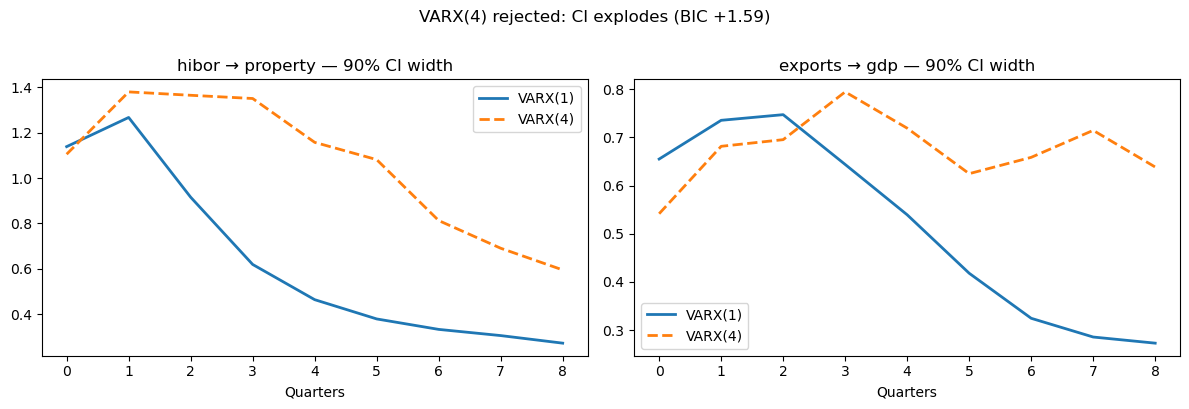

In [63]:
# VARX(4): OLS overfit, exports → gdp disappears -> rejected
# 27 params/eq on 107 obs = 3.9:1 ratio. OLS memorises noise, CIs explode.

v4_c = VAR(df[ENDOG_OLD], exog=df[EXOG]).fit(maxlags=4)

k1 = 1 * len(ENDOG_OLD) + len(EXOG) + 1   # 9 params/eq
k4 = 4 * len(ENDOG_OLD) + len(EXOG) + 1   # 27 params/eq
nobs = v4_c.nobs

print(f'Model comparison:')
print(f'  VARX(1): {k1} params/eq  |  BIC={v1.bic:.4f}')
print(f'  VARX(4): {k4} params/eq  |  BIC={v4_c.bic:.4f}  (BIC +{v4_c.bic - v1.bic:.2f})')
print(f'  VARX(4) obs={nobs}  params/obs = {k4}/{nobs} = {k4/nobs:.2f}')
print()
print('Since VARX(4) has much higher BIC, very high params/obs ratio and more insiginificant coefficients, I reject it as an overfit model.')

irf1 = v1.irf(periods=8)
irf4 = v4_c.irf(periods=8)
lo1, hi1 = irf1.errband_mc(orth=True, repl=500, signif=0.10)
lo4, hi4 = irf4.errband_mc(orth=True, repl=500, signif=0.10)

si = {v: i for i, v in enumerate(ENDOG_OLD)}
channels = [
    (si['hibor_3m'],              si['hk_property_price_qoq'], 'hibor → property'),
    (si['hk_exports_china_yoy'],  si['gdp_growth'],            'exports → gdp'),
]

print('Bootstrap IRF (90% MC, 500 repl):')
print(f'{"Channel":<22} {"h":>3}  {"VARX(1)":>22}  {"VARX(4)":>22}')
print('-' * 78)
for imp, resp, label in channels:
    for h in [1, 2, 4]:
        l1, h1 = lo1[h, resp, imp], hi1[h, resp, imp]
        l4, h4 = lo4[h, resp, imp], hi4[h, resp, imp]
        s1 = 'sig' if not (l1 < 0 < h1) else 'x0 '
        s4 = 'sig' if not (l4 < 0 < h4) else 'x0 '
        print(f'{label:<22} {h:>3}  ({l1:+.3f},{h1:+.3f}) {s1}  ({l4:+.3f},{h4:+.3f}) {s4}')
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (imp, resp, title) in zip(axes, channels):
    ax.plot(hi1[:, resp, imp] - lo1[:, resp, imp], lw=2, label='VARX(1)')
    ax.plot(hi4[:, resp, imp] - lo4[:, resp, imp], lw=2, ls='--', label='VARX(4)')
    ax.set_title(f'{title} — 90% CI width')
    ax.set_xlabel('Quarters')
    ax.legend()
fig.suptitle(f'VARX(4) rejected: CI explodes (BIC +{v4_c.bic - v1.bic:.2f})', y=1.01)
plt.tight_layout()
plt.savefig('output/varx4_rejection.png', dpi=150, bbox_inches='tight')
plt.show()


## BVARX(4) vs VARX(1) comparison


IRF comparison — VARX(1) vs BVARX(4) Litterman (90% bands)
Channel                h               VARX(1)              BVARX(4)
----------------------------------------------------------------------
hibor → property       1  (-1.641,-0.396) sig  (-0.641,-0.217) sig
hibor → property       2  (-0.963,-0.067) sig  (-0.309,+0.096)  x0
hibor → property       4  (-0.326,+0.108)  x0  (-0.119,+0.086)  x0

exports → gdp          1  (+0.114,+0.802) sig  (+0.293,+0.506) sig
exports → gdp          2  (-0.169,+0.537)  x0  (+0.114,+0.371) sig
exports → gdp          4  (-0.278,+0.226)  x0  (-0.138,+0.098)  x0

gdp → cpi              1  (+0.045,+0.327) sig  (+0.091,+0.177) sig
gdp → cpi              2  (+0.157,+0.500) sig  (+0.135,+0.253) sig
gdp → cpi              4  (+0.269,+0.668) sig  (+0.177,+0.318) sig

FEVD at h=8 (BVARX(4) Litterman):
  HIBOR share in property: 7%
  Exports share in GDP:    19%
  HIBOR own-share:         85%


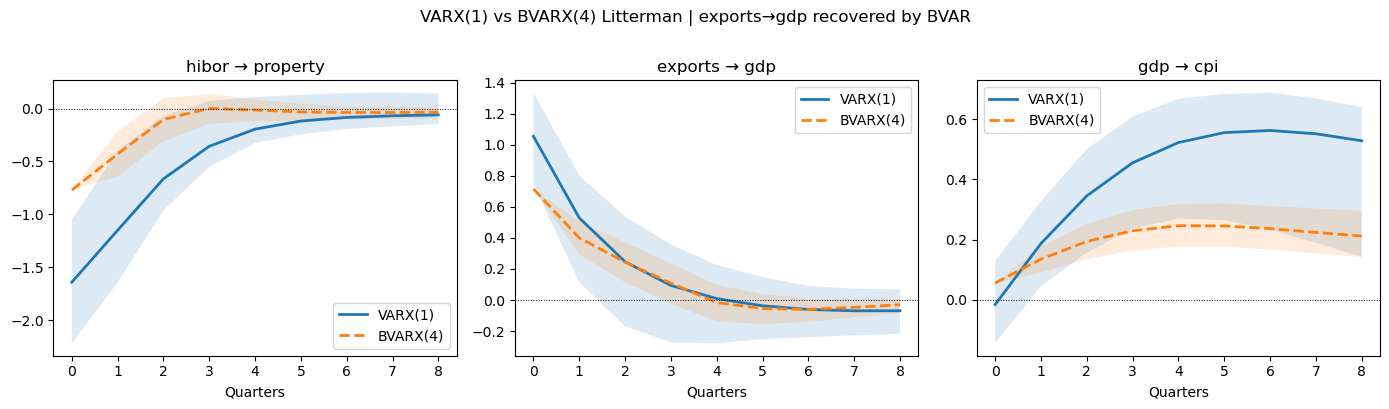

In [64]:
# BVARX(4) vs VARX(1)
# Litterman (1986) default prior, with no optimization yet.

Y4   = df[ENDOG_OLD].values.astype(float)
X    = df[EXOG].values.astype(float)
idx4 = {v: i for i, v in enumerate(ENDOG_OLD)}

bvar4 = MinnesotaBayesianVar(
    endogenous=Y4, exogenous=X, lags=4,
    pi1=0.1, pi2=0.5, pi3=1,
    ar_coefficients=AR_COEF_OLD,
    iterations=2000, credibility_level=0.90, verbose=False
)
bvar4.estimate()
irf4, _ = bvar4.impulse_response_function(h=9, credibility_level=0.90)
fevd4   = bvar4.forecast_error_variance_decomposition(h=8, credibility_level=0.90)

channels = [
    (idx4['hibor_3m'], idx4['hk_property_price_qoq'], 'hibor → property'),
    (idx4['hk_exports_china_yoy'], idx4['gdp_growth'], 'exports → gdp'),
    (idx4['gdp_growth'], idx4['cpi_inflation'],         'gdp → cpi'),
]

irf_v1r = v1.irf(periods=8)
lo_v1r, hi_v1r = irf_v1r.errband_mc(orth=True, repl=500, signif=0.10)

print('IRF comparison — VARX(1) vs BVARX(4) Litterman (90% bands)')
print(f'{"Channel":<20} {"h":>3}  {"VARX(1)":>20}  {"BVARX(4)":>20}')
print('-'*70)
for imp, resp, label in channels:
    for h in [1, 2, 4]:
        v1_lo = lo_v1r[h, resp, imp]; v1_hi = hi_v1r[h, resp, imp]
        b4_lo = irf4[resp, imp, h, 1]; b4_hi = irf4[resp, imp, h, 2]
        v1_s  = 'sig' if not (v1_lo < 0 < v1_hi) else 'x0'
        b4_s  = 'sig' if not (b4_lo < 0 < b4_hi) else 'x0'
        print(f'{label:<20} {h:>3}  ({v1_lo:+.3f},{v1_hi:+.3f}){v1_s:>4}  ({b4_lo:+.3f},{b4_hi:+.3f}){b4_s:>4}')
    print()

print('FEVD at h=8 (BVARX(4) Litterman):')
print(f'  HIBOR share in property: {fevd4[idx4["hk_property_price_qoq"],idx4["hibor_3m"],7,0]*100:.0f}%')
print(f'  Exports share in GDP:    {fevd4[idx4["gdp_growth"],idx4["hk_exports_china_yoy"],7,0]*100:.0f}%')
print(f'  HIBOR own-share:         {fevd4[idx4["hibor_3m"],idx4["hibor_3m"],7,0]*100:.0f}%')

t = range(9)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (imp, resp, title) in zip(axes, channels):
    ax.plot(t, irf_v1r.orth_irfs[:, resp, imp], lw=2, label='VARX(1)')
    ax.fill_between(t, lo_v1r[:, resp, imp], hi_v1r[:, resp, imp], alpha=0.15)
    ax.plot(t, irf4[resp, imp, :, 0], lw=2, ls='--', label='BVARX(4)')
    ax.fill_between(t, irf4[resp, imp, :, 1], irf4[resp, imp, :, 2], alpha=0.15)
    ax.axhline(0, color='k', lw=0.7, ls=':')
    ax.set_title(title)
    ax.set_xlabel('Quarters')
    ax.legend()
fig.suptitle('VARX(1) vs BVARX(4) Litterman | exports→gdp recovered by BVAR', y=1.01)
plt.tight_layout()
plt.savefig('output/bvarx4_irf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Hyperparameters and fit: BVARX(4)
- Check lag length and Minnesota hyperparameters.
- p=4 fits quarterly timing; p=5 adds extra parameters.
- p=4 is the first lag where LB failures drop from 3/6 to 2/6.
- Use p=4 as the conservative quarterly/spec choice, not because it has the highest ML.


In [65]:
# Checking lag first.
# Lag-length ML grid: ENDOG_OLD ordering

Y5 = df[ENDOG_OLD].values.astype(float)
X  = df[EXOG].values.astype(float)

print(f'{"p":>4}  {"opt_pi1":>8}  {"opt_pi2":>8}  {"ML":>12}  {"LB fail":>8}')
print('-' * 52)
opt_results = {}
for p in range(1, 8):
    bv = MinnesotaBayesianVar(
        endogenous=Y5, exogenous=X, lags=p,
        hyperparameter_optimization=True,
        iterations=2000, credibility_level=0.90, verbose=False
    )
    bv.estimate()
    ml = bv.marginal_likelihood()
    bv.insample_fit()
    resid = bv.residual_estimates[:, :, 0]
    lb_fails = sum(
        acorr_ljungbox(resid[:, i], lags=[8], return_df=True)['lb_pvalue'].values[0] < 0.05
        for i in range(len(ENDOG_OLD))
    )
    opt_results[p] = {'ml': ml, 'pi1': bv.pi1, 'pi2': bv.pi2, 'lb': lb_fails}
    print(f'{p:>4}  {bv.pi1:>8.4f}  {bv.pi2:>8.4f}  {ml:>12.4f}  {lb_fails:>5}/6')

print(f'\np=4: ML={opt_results[4]["ml"]:.2f} | pi1={opt_results[4]["pi1"]:.4f} | LB={opt_results[4]["lb"]}/6')


   p   opt_pi1   opt_pi2            ML   LB fail
----------------------------------------------------
   1    0.0481    1.0000     -539.7396      3/6
   2    0.0449    1.0000     -551.3241      3/6
   3    0.0471    1.0000     -534.4644      3/6
   4    0.0855    1.0000     -534.2911      2/6
   5    0.1013    1.0000     -532.6522      2/6
   6    0.1207    1.0000     -532.7379      2/6
   7    0.1416    0.9856     -533.1928      2/6

p=4: ML=-534.29 | pi1=0.0855 | LB=2/6


## Data checks: ADF + KPSS stationarity 
- While BVAR allows I(1), I still would like to know the data.
- Key: is the LJB test fail because of non-stationarity (model can't capture the trend), or structural break?

In [66]:
# ADF + KPSS 
prop_idx = df['hk_property_price_idx']

test_series = {
    'hk_exports_china_yoy':  df['hk_exports_china_yoy'],
    'gdp_growth':            df['gdp_growth'],
    'cpi_inflation':         df['cpi_inflation'],
    'unemployment':          df['unemployment'],
    'hibor_3m':              df['hibor_3m'],
    'hk_property_price_qoq': df['hk_property_price_qoq'],
    'hk_property_price_idx': prop_idx,
}

print('ADF + KPSS stationarity audit:')
print(f'{"Series":<28} {"ADF_p":>8}  {"KPSS_p":>8}  Verdict')
print('-' * 65)
i1_candidates = []
for name, s in test_series.items():
    s_clean = s.dropna()
    adf_p = adfuller(s_clean, autolag='BIC')[1]
    try:
        kpss_stat, kpss_p, _, _ = kpss(s_clean, regression='c', nlags='auto')
        kpss_p_display = kpss_p
    except Exception:
        kpss_p_display = np.nan
    if adf_p > 0.05 and (np.isnan(kpss_p_display) or kpss_p_display < 0.05):
        verdict = 'I(1)'
        i1_candidates.append(name)
    elif adf_p < 0.05 and (np.isnan(kpss_p_display) or kpss_p_display > 0.05):
        verdict = 'I(0)'
    else:
        verdict = 'ambiguous'
    kpss_str = f'{kpss_p_display:.4f}' if not np.isnan(kpss_p_display) else 'nan'
    print(f'{name:<28} {adf_p:>8.4f}  {kpss_str:>8}  {verdict}')

print(f'\nI(1) candidates: {i1_candidates}')
print('Endogenous I(1) block for Johansen: [unemployment, cpi_inflation, hk_property_price_idx]')


ADF + KPSS stationarity audit:
Series                          ADF_p    KPSS_p  Verdict
-----------------------------------------------------------------
hk_exports_china_yoy           0.0000    0.1000  I(0)
gdp_growth                     0.0161    0.1000  I(0)
cpi_inflation                  0.1526    0.0202  I(1)
unemployment                   0.0821    0.0100  I(1)
hibor_3m                       0.0368    0.0495  ambiguous
hk_property_price_qoq          0.0000    0.0830  I(0)
hk_property_price_idx          0.8222    0.0100  I(1)

I(1) candidates: ['cpi_inflation', 'unemployment', 'hk_property_price_idx']
Endogenous I(1) block for Johansen: [unemployment, cpi_inflation, hk_property_price_idx]


### Delta-u robustness: One defensive robustness check
- Unemployment is borderline I(1).
- I wonder if I should difference it before putting it in the VAR.
- This cell asks: if I replace unemployment with Δunemployment (quarter-on-quarter change), do the main IRF results flip?

- Result: No. Both key channels give the same sig/not-sig verdict. 
- Decision: keep unemployment in levels

In [67]:
df_du = df.copy()
df_du['unemployment'] = df['unemployment'].diff()
df_du = df_du.dropna()

AR_COEF_DU = AR_COEF_OLD.copy()
AR_COEF_DU[ENDOG_OLD.index('unemployment')] = df_du['unemployment'].autocorr(lag=1)
print(f"Δu AR coefficient: {AR_COEF_DU[ENDOG_OLD.index('unemployment')]:.3f}")

bvar_base = MinnesotaBayesianVar(
    endogenous=df[ENDOG_OLD].values, exogenous=df[EXOG].values,
    lags=LAGS, pi1=PI1, pi2=PI2, pi3=PI3,
    ar_coefficients=AR_COEF_OLD,
    iterations=2000, credibility_level=0.90, verbose=False
)
bvar_base.estimate()
irf_base, _ = bvar_base.impulse_response_function(h=9, credibility_level=0.90)

bvar_du = MinnesotaBayesianVar(
    endogenous=df_du[ENDOG_OLD].values, exogenous=df_du[EXOG].values,
    lags=LAGS, pi1=PI1, pi2=PI2, pi3=PI3,
    ar_coefficients=AR_COEF_DU,
    iterations=2000, credibility_level=0.90, verbose=False
)
bvar_du.estimate()
irf_du, _ = bvar_du.impulse_response_function(h=9, credibility_level=0.90)

idx4 = {v: i for i, v in enumerate(ENDOG_OLD)}
checks = [('HIBOR → Property', idx4['hibor_3m'], idx4['hk_property_price_qoq']),
          ('Exports → GDP',    idx4['hk_exports_china_yoy'], idx4['gdp_growth'])]

print('IRF at h=2 — baseline vs Δu robustness:')
print(f'{"Channel":<22} {"Base CI":>22}  {"Δu CI":>22}  Verdict')
print('-' * 75)
for label, imp, resp in checks:
    b_lo = irf_base[resp, imp, 2, 1]; b_hi = irf_base[resp, imp, 2, 2]
    d_lo = irf_du[resp, imp, 2, 1];   d_hi = irf_du[resp, imp, 2, 2]
    b_s  = 'sig' if not (b_lo < 0 < b_hi) else 'x0'
    d_s  = 'sig' if not (d_lo < 0 < d_hi) else 'x0'
    verdict = 'PASS' if b_s == d_s else 'CHANGED'
    print(f'{label:<22} ({b_lo:+.3f},{b_hi:+.3f}) {b_s}  ({d_lo:+.3f},{d_hi:+.3f}) {d_s}  {verdict}')

print('\nConclusion: Keep unemployment in levels. One limitation sentence required.')

Δu AR coefficient: 0.471
IRF at h=2 — baseline vs Δu robustness:
Channel                               Base CI                   Δu CI  Verdict
---------------------------------------------------------------------------
HIBOR → Property       (-0.454,+0.104) x0  (-0.458,+0.077) x0  PASS
Exports → GDP          (+0.093,+0.412) sig  (+0.047,+0.376) sig  PASS

Conclusion: Keep unemployment in levels. One limitation sentence required.


### Johansen check: BVAR or BVEC?
- Test whether the I(1) variables share a long-run relation.
- Variables: unemployment, CPI, property index.
- Result: rank=0. Use BVAR, not BVECM.


In [68]:
i1_block = pd.DataFrame({
    'unemployment':         df['unemployment'],
    'cpi_inflation':        df['cpi_inflation'],
    'hk_property_price_idx': prop_idx,
}).dropna()

print(f'I(1) endogenous block: n={len(i1_block)} obs, variables: {list(i1_block.columns)}')
print()

res = coint_johansen(i1_block, det_order=1, k_ar_diff=1)
print('Johansen results:')
print(f'  Trace statistics:      {[round(float(x),2) for x in res.lr1]}')
print(f'  Trace CV 95%:          {[round(float(x),2) for x in res.cvt[:, 1]]}')
print(f'  Max-eigenvalue stats:  {[round(float(x),2) for x in res.lr2]}')
print(f'  Max-eig CV 95%:        {[round(float(x),2) for x in res.cvm[:, 1]]}')
print()

rank = 0
for i, (stat, cv) in enumerate(zip(res.lr1, res.cvt[:, 1])):
    if float(stat) > float(cv):
        rank = i + 1
print(f'Cointegrating rank at 95%: {rank}')
if rank == 0:
    print('VECM not warranted.')

I(1) endogenous block: n=113 obs, variables: ['unemployment', 'cpi_inflation', 'hk_property_price_idx']

Johansen results:
  Trace statistics:      [32.78, 12.57, 3.67]
  Trace CV 95%:          [35.01, 18.4, 3.84]
  Max-eigenvalue stats:  [20.22, 8.89, 3.67]
  Max-eig CV 95%:        [24.25, 17.15, 3.84]

Cointegrating rank at 95%: 0
VECM not warranted.


### Exogenous lag check
Add `us_ffr_lag1` to see whether the residual failures are just omitted exogenous lag structure. Result: no. Keep q=0.

In [69]:
# q=0 vs q=1 exogenous lag check
idx = {v: i for i, v in enumerate(ENDOG_CANONICAL)}
df_q1 = df.assign(us_ffr_lag1=df['us_ffr'].shift(1)).dropna()

irf_lag = {}
resid_lag = {}
for name, xcols in [('q0', EXOG), ('q1', EXOG + ['us_ffr_lag1'])]:
    m = MinnesotaBayesianVar(
        endogenous=df_q1[ENDOG_CANONICAL].values.astype(float),
        exogenous=df_q1[xcols].values.astype(float),
        lags=LAGS, pi1=PI1, pi2=PI2, pi3=PI3,
        ar_coefficients=AR_COEF_CANONICAL,
        iterations=2000, credibility_level=0.90, verbose=False,
    )
    m.estimate()
    irf_lag[name], _ = m.impulse_response_function(h=9, credibility_level=0.90)
    m.insample_fit()
    resid_lag[name] = m.residual_estimates[:, :, 0]

print(f'n={len(df_q1)} obs')
print('Ljung-Box at lag=8')
for var in ['gdp_growth', 'cpi_inflation']:
    i = idx[var]
    p0 = acorr_ljungbox(resid_lag['q0'][:, i], lags=[8], return_df=True)['lb_pvalue'].iloc[0]
    p1 = acorr_ljungbox(resid_lag['q1'][:, i], lags=[8], return_df=True)['lb_pvalue'].iloc[0]
    print(f'{var:<22} q0={p0:.4f}  q1={p1:.4f}')

channels = [
    ('hibor→property', 'hibor_3m', 'hk_property_price_qoq'),
    ('exports→gdp', 'hk_exports_china_yoy', 'gdp_growth'),
    ('hibor→gdp', 'hibor_3m', 'gdp_growth'),
    ('property→gdp', 'hk_property_price_qoq', 'gdp_growth'),
]

print('IRF 90% bands: q0 vs q1')
for label, shock, response in channels:
    print(label)
    for h in [1, 2, 4]:
        s, r = idx[shock], idx[response]
        q0 = irf_lag['q0'][r, s, h, 1:3]
        q1 = irf_lag['q1'][r, s, h, 1:3]
        print(f'  h={h}: q0=({q0[0]:+.3f},{q0[1]:+.3f})  q1=({q1[0]:+.3f},{q1[1]:+.3f})')

n=112 obs
Ljung-Box at lag=8
gdp_growth             q0=0.0000  q1=0.0001
cpi_inflation          q0=0.0023  q1=0.0019
IRF 90% bands: q0 vs q1
hibor→property
  h=1: q0=(-0.976,-0.325)  q1=(-0.950,-0.288)
  h=2: q0=(-0.553,+0.062)  q1=(-0.557,+0.108)
  h=4: q0=(-0.231,+0.072)  q1=(-0.305,+0.096)
exports→gdp
  h=1: q0=(+0.261,+0.536)  q1=(+0.296,+0.559)
  h=2: q0=(+0.060,+0.372)  q1=(+0.093,+0.417)
  h=4: q0=(-0.197,+0.114)  q1=(-0.169,+0.142)
hibor→gdp
  h=1: q0=(-0.411,-0.049)  q1=(-0.356,+0.018)
  h=2: q0=(-0.491,-0.127)  q1=(-0.429,-0.014)
  h=4: q0=(-0.295,-0.062)  q1=(-0.267,+0.057)
property→gdp
  h=1: q0=(+0.334,+0.623)  q1=(+0.344,+0.643)
  h=2: q0=(+0.252,+0.567)  q1=(+0.254,+0.597)
  h=4: q0=(-0.069,+0.206)  q1=(-0.047,+0.235)


### ZLB asymmetry check

Threshold LP for HIBOR -> property.

- Normal-rate regime: significant negative response at h=1.
- ZIRP regime: not significant; confidence bands are wide.
- Use as appendix/report material, not the main notebook result.


In [70]:
# ZLB setup
ZIRP_THRESHOLD = 0.25
zirp = (df['us_ffr'] < ZIRP_THRESHOLD).astype(float).values
endog_arr = df[ENDOG_CANONICAL].values.astype(float)
T = len(df)

zirp_dates = df.index[df['us_ffr'] < ZIRP_THRESHOLD]
print(f"ZIRP obs: {int(zirp.sum())} / {T}  ({zirp.mean()*100:.1f}%)")
if len(zirp_dates):
    print(f"First: {zirp_dates[0].strftime('%Y-%m')}  Last: {zirp_dates[-1].strftime('%Y-%m')}")


ZIRP obs: 36 / 113  (31.9%)
First: 2009-01  Last: 2022-01


In [71]:
# threshold LP-IRF estimation
H_MAX = 8
Z_90  = 1.645
resp_i  = ENDOG_CANONICAL.index('hk_property_price_qoq')
shock_i = ENDOG_CANONICAL.index('hibor_3m')

beta_norm = np.zeros(H_MAX + 1)
beta_zirp = np.zeros(H_MAX + 1)
se_norm   = np.zeros(H_MAX + 1)
se_zirp   = np.zeros(H_MAX + 1)

for h in range(H_MAX + 1):
    t_start = LAGS
    t_end   = T - h
    n_obs   = t_end - t_start

    y      = endog_arr[t_start + h : t_end + h, resp_i]
    shock  = endog_arr[t_start:t_end, shock_i]
    zirp_t = zirp[t_start:t_end]
    norm_t = 1.0 - zirp_t

    regime_cols = np.column_stack([
        norm_t,           # α^norm intercept
        zirp_t,           # α^ZIRP intercept
        shock * norm_t,   # β^norm
        shock * zirp_t,   # β^ZIRP
    ])
    controls = np.hstack([endog_arr[t_start - lag : t_end - lag, :]
                          for lag in range(1, LAGS + 1)])
    X = np.hstack([regime_cols, controls])
    bw  = max(h + 1, int(n_obs ** (1/3)))
    res = OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': bw, 'use_correction': True})
    beta_norm[h] = res.params[2]
    beta_zirp[h] = res.params[3]
    se_norm[h]   = res.bse[2]
    se_zirp[h]   = res.bse[3]

rows_zlb = []
for h in range(H_MAX + 1):
    lo_n = beta_norm[h] - Z_90*se_norm[h]; hi_n = beta_norm[h] + Z_90*se_norm[h]
    lo_z = beta_zirp[h] - Z_90*se_zirp[h]; hi_z = beta_zirp[h] + Z_90*se_zirp[h]
    rows_zlb.append({'h': h,
                     'β normal': round(beta_norm[h], 3),
                     'CI normal': f'({lo_n:+.3f}, {hi_n:+.3f})',
                     'sig normal': 'sig' if lo_n*hi_n > 0 else 'x0',
                     'β ZIRP': round(beta_zirp[h], 3),
                     'CI ZIRP': f'({lo_z:+.3f}, {hi_z:+.3f})',
                     'sig ZIRP': 'sig' if lo_z*hi_z > 0 else 'x0'})
display(pd.DataFrame(rows_zlb))


,h,β normal,CI normal,sig normal,β ZIRP,CI ZIRP,sig ZIRP
0,0,-2.090,"(-3.532, -0.649)",sig,-1.022,"(-7.893, +5.850)",x0
1,1,-2.686,"(-3.796, -1.576)",sig,-0.514,"(-7.913, +6.884)",x0
2,2,-0.961,"(-2.370, +0.447)",x0,0.360,"(-9.150, +9.871)",x0
3,3,0.099,"(-1.947, +2.145)",x0,0.310,"(-8.158, +8.779)",x0
4,4,-0.663,"(-2.480, +1.155)",x0,1.965,"(-7.151, +11.082)",x0
5,5,-2.855,"(-3.761, -1.948)",sig,-3.582,"(-12.587, +5.423)",x0
6,6,-2.016,"(-3.174, -0.858)",sig,-5.177,"(-10.970, +0.616)",x0
7,7,-1.309,"(-2.031, -0.587)",sig,-4.887,"(-9.979, +0.204)",x0
8,8,-0.963,"(-1.798, -0.127)",sig,-2.465,"(-8.196, +3.266)",x0


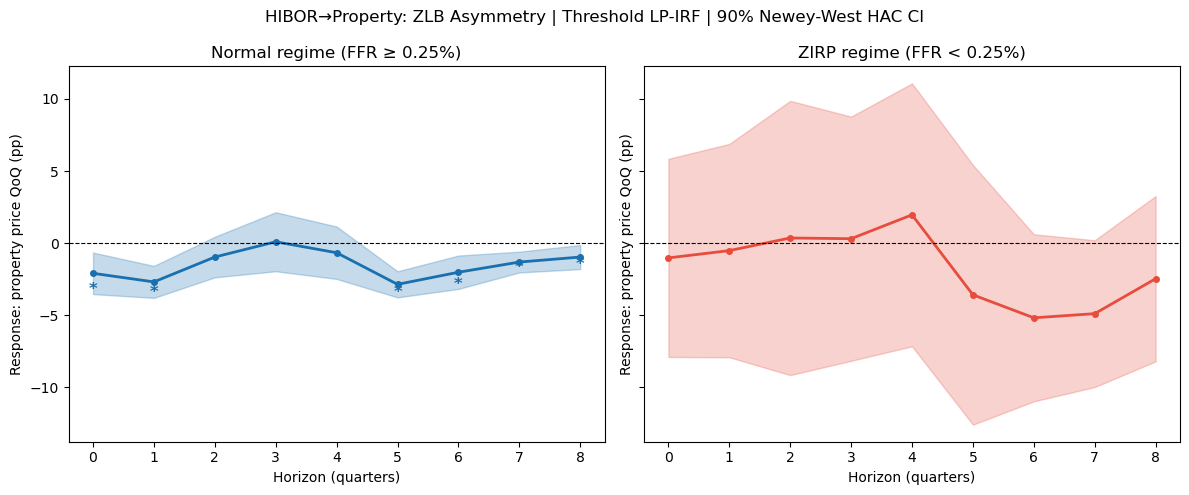

In [72]:
# ZLB asymmetry plot
horizons = np.arange(H_MAX + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, beta, se, label, color in zip(
    axes,
    [beta_norm, beta_zirp],
    [se_norm,   se_zirp],
    ['Normal regime (FFR ≥ 0.25%)', 'ZIRP regime (FFR < 0.25%)'],
    ['#1a6faf',                      '#e74c3c'],
):
    lo = beta - Z_90 * se
    hi = beta + Z_90 * se
    ax.fill_between(horizons, lo, hi, alpha=0.25, color=color)
    ax.plot(horizons, beta, color=color, lw=2, marker='o', ms=4)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    for h in range(H_MAX + 1):
        if lo[h] * hi[h] > 0:
            ax.annotate('*', (h, max(abs(hi[h]), abs(lo[h])) * np.sign(beta[h]) + 0.03),
                        ha='center', fontsize=12, color=color, fontweight='bold')
    ax.set_title(label)
    ax.set_xlabel('Horizon (quarters)')
    ax.set_ylabel('Response: property price QoQ (pp)')
    ax.set_xticks(horizons)

fig.suptitle('HIBOR→Property: ZLB Asymmetry | Threshold LP-IRF | 90% Newey-West HAC CI')
plt.tight_layout()
plt.savefig('output/phase9c_zlb_asymmetry.png', dpi=150, bbox_inches='tight')
plt.show()

### OOS diagnostic
Conditional on realized exogenous paths. Benchmark is persistence first: random walk and AR(1).

OOS done: 1.2s | 28 windows


Benchmark     RW                  AR1                VARX1              
h              1      2      4      1      2      4      1      2      4
Variable                                                                
HIBOR      0.831  0.666  0.491  0.838  0.682  0.528  0.824  0.795  0.835
Exports    0.976  0.963  0.796  1.008  1.074  1.077  0.890  0.926  0.952
Property   0.945  0.953  1.177  1.073  1.177  1.201  0.868  0.896  0.908
GDP        0.769  0.657  0.517  0.804  0.717  0.637  0.908  0.911  0.900
CPI        1.108  1.219  1.272  1.143  1.301  1.462  0.982  0.947  0.820
Unemp      0.900  0.842  0.809  0.911  0.862  0.846  0.969  0.931  0.840

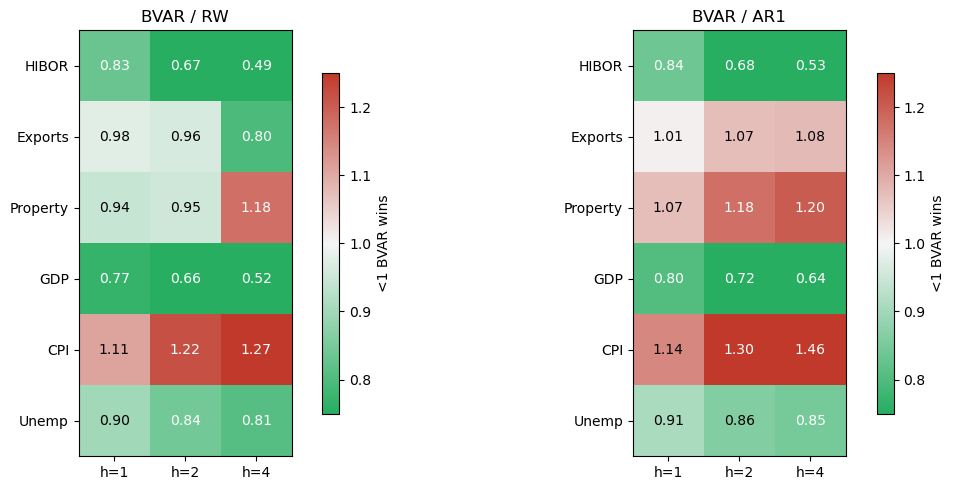

In [73]:
# BVAR vs naive OOS benchmarks
Y = df[ENDOG_CANONICAL].values.astype(float)
X = df[EXOG].values.astype(float)
H = [1, 2, 4]
T0 = 85
labels = ['HIBOR', 'Exports', 'Property', 'GDP', 'CPI', 'Unemp']

pred = {k: {h: [] for h in H} for k in ['BVAR', 'RW', 'AR1', 'VARX1']}
actual = {h: [] for h in H}

t0 = time.time()
for t in range(T0, len(Y)):
    train = df.iloc[:t]
    varx1 = VAR(train[ENDOG_CANONICAL], exog=train[EXOG]).fit(maxlags=1)
    bvar = MinnesotaBayesianVar(
        endogenous=Y[:t], exogenous=X[:t], lags=LAGS,
        pi1=PI1, pi2=PI2, pi3=PI3,
        ar_coefficients=AR_COEF_CANONICAL,
        iterations=300, credibility_level=0.90, verbose=False,
    )
    bvar.estimate()
    for h in H:
        if t + h > len(Y):
            continue
        xf = X[t:t+h]
        pred['BVAR'][h].append(bvar.forecast(h=h, credibility_level=0.90, Z_p=xf)[h-1, :, 0])
        pred['VARX1'][h].append(varx1.forecast(train[ENDOG_CANONICAL].values[-1:], steps=h, exog_future=xf)[h-1])
        pred['RW'][h].append(Y[t-1])
        actual[h].append(Y[t+h-1])
        pred['AR1'][h].append([
            AutoReg(Y[:t, j], lags=1, old_names=False).fit().predict(start=t, end=t+h-1)[h-1]
            for j in range(len(ENDOG_CANONICAL))
        ])
print(f'OOS done: {time.time() - t0:.1f}s | {len(Y) - T0} windows')

rows = []
for base in ['RW', 'AR1', 'VARX1']:
    for h in H:
        y = np.array(actual[h])
        rb = np.sqrt(np.mean((np.array(pred['BVAR'][h]) - y) ** 2, axis=0))
        rr = np.sqrt(np.mean((np.array(pred[base][h]) - y) ** 2, axis=0))
        rows += [{'Variable': labels[i], 'Benchmark': base, 'h': h, 'ratio': rb[i] / rr[i]} for i in range(6)]

oos = pd.DataFrame(rows)
display(oos.pivot(index='Variable', columns=['Benchmark', 'h'], values='ratio').loc[labels].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, base in zip(axes, ['RW', 'AR1']):
    mat = oos[oos['Benchmark'] == base].pivot(index='Variable', columns='h', values='ratio').loc[labels, H].values
    im = ax.imshow(mat, cmap=mcolors.LinearSegmentedColormap.from_list('bvar', ['#27ae60', '#f5f5f5', '#c0392b']), vmin=0.75, vmax=1.25)
    ax.set_xticks(range(len(H))); ax.set_xticklabels([f'h={h}' for h in H])
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_title(f'BVAR / {base}')
    for i in range(len(labels)):
        for j in range(len(H)):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', color='white' if mat[i, j] < 0.85 or mat[i, j] > 1.15 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8, label='<1 BVAR wins')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'oos_rmse_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()

### FEVD and historical decomposition checks
FEVD: GDP row is the point. Historical decomposition: accounting check; crisis episodes are mostly GDP-own shocks.


FEVD at h=1
          HIBOR  Exports  Property   GDP   CPI  Unemp
HIBOR     100.0      0.0       0.0   0.0   0.0    0.0
Exports     1.1     98.9       0.0   0.0   0.0    0.0
Property   10.0      3.6      86.4   0.0   0.0    0.0
GDP         3.4     18.4      15.7  62.5   0.0    0.0
CPI         1.0      0.6       0.0   0.5  97.8    0.0
Unemp       3.4      0.5       8.1  14.6   0.1   73.3

FEVD at h=4
          HIBOR  Exports  Property   GDP   CPI  Unemp
HIBOR      96.8      2.0       0.4   0.3   0.3    0.3
Exports     2.6     95.4       0.4   0.3   1.0    0.2
Property   12.3      3.7      83.2   0.3   0.4    0.2
GDP         8.0     16.5      20.8  53.1   1.3    0.3
CPI         4.2      2.0       5.0   5.9  76.4    6.4
Unemp       2.4      0.4      16.3  20.7   0.8   59.4

FEVD at h=8
          HIBOR  Exports  Property   GDP   CPI  Unemp
HIBOR      94.1      2.9       0.6   0.5   1.0    0.8
Exports     3.1     91.0       1.3   1.2   2.8    0.6
Property   12.3      4.2      81.7   0.6   

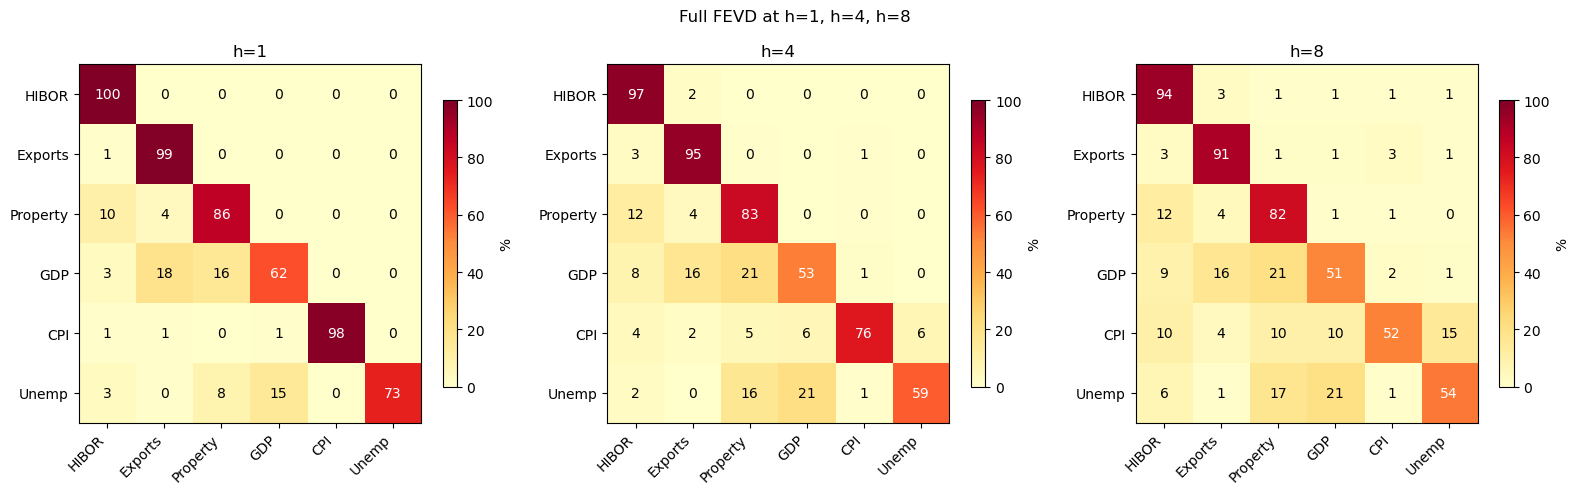

In [74]:
# Full FEVD: GDP row is the useful part.
idx_c = {v: i for i, v in enumerate(ENDOG_CANONICAL)}
bvar_c = MinnesotaBayesianVar(
        endogenous=df[ENDOG_CANONICAL].values.astype(float),
        exogenous=df[EXOG].values.astype(float),
        lags=LAGS, pi1=PI1, pi2=PI2, pi3=PI3,
        ar_coefficients=AR_COEF_CANONICAL,
        iterations=2000, credibility_level=0.90, verbose=False,
    )
bvar_c.estimate()

fevd_c = bvar_c.forecast_error_variance_decomposition(h=8, credibility_level=0.90)
labels = ['HIBOR', 'Exports', 'Property', 'GDP', 'CPI', 'Unemp']
for label, h in [('h=1', 0), ('h=4', 3), ('h=8', 7)]:
    mat = fevd_c[:, :, h, 0] * 100
    print()
    print(f'FEVD at {label}')
    print(pd.DataFrame(mat.round(1), index=labels, columns=labels).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, h) in zip(axes, [('h=1', 0), ('h=4', 3), ('h=8', 7)]):
    mat = fevd_c[:, :, h, 0] * 100
    im = ax.imshow(mat, vmin=0, vmax=100, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(6)); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(6)); ax.set_yticklabels(labels)
    ax.set_title(label)
    for i in range(6):
        for j in range(6):
            ax.text(j, i, f'{mat[i, j]:.0f}', ha='center', va='center', color='white' if mat[i, j] > 45 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8, label='%')
plt.suptitle('Full FEVD at h=1, h=4, h=8')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'full_6x6_fevd.png', dpi=150, bbox_inches='tight')
plt.show()

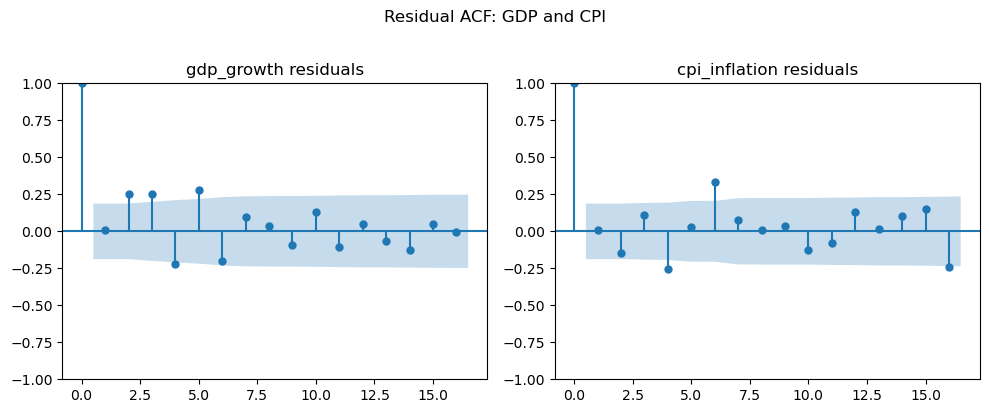

Variable                             R²      RMSE      LB p  Status
-----------------------------------------------------------------
hibor_3m                          0.953     0.416    0.2600  pass
hk_exports_china_yoy              0.656     7.318    0.2091  pass
hk_property_price_qoq             0.411     3.407    0.4228  pass
gdp_growth                        0.792     1.794    0.0000  FAIL
cpi_inflation                     0.915     0.746    0.0015  FAIL
unemployment                      0.949     0.331    0.5939  pass


In [75]:
# In-sample residuals: ACF first, then LB table
bvar_c.insample_fit()
resid_is = bvar_c.residual_estimates[:, :, 0]
T_eff    = resid_is.shape[0]
Y_is     = df[ENDOG_CANONICAL].values.astype(float)[-T_eff:]

# ACF/LB residual diagnostic
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['gdp_growth', 'cpi_inflation']):
    plot_acf(resid_is[:, ENDOG_CANONICAL.index(col)], lags=16, ax=ax, alpha=0.05)
    ax.set_title(f'{col} residuals')
plt.suptitle('Residual ACF: GDP and CPI', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'insample_fit_acf.png', dpi=150, bbox_inches='tight')
plt.show()

# LB table: 2/6 fail
print(f'{"Variable":<32} {"R²":>6}  {"RMSE":>8}  {"LB p":>8}  Status')
print('-' * 65)
for i, col in enumerate(ENDOG_CANONICAL):
    ss_res = np.sum(resid_is[:, i]**2)
    ss_tot = np.sum((Y_is[:, i] - Y_is[:, i].mean())**2)
    r2   = 1 - ss_res / ss_tot
    rmse = np.sqrt(ss_res / T_eff)
    lb_p = acorr_ljungbox(resid_is[:, i], lags=[8], return_df=True)['lb_pvalue'].values[0]
    print(f'{col:<32} {r2:>6.3f}  {rmse:>8.3f}  {lb_p:>8.4f}  {"FAIL" if lb_p<0.05 else "pass"}')

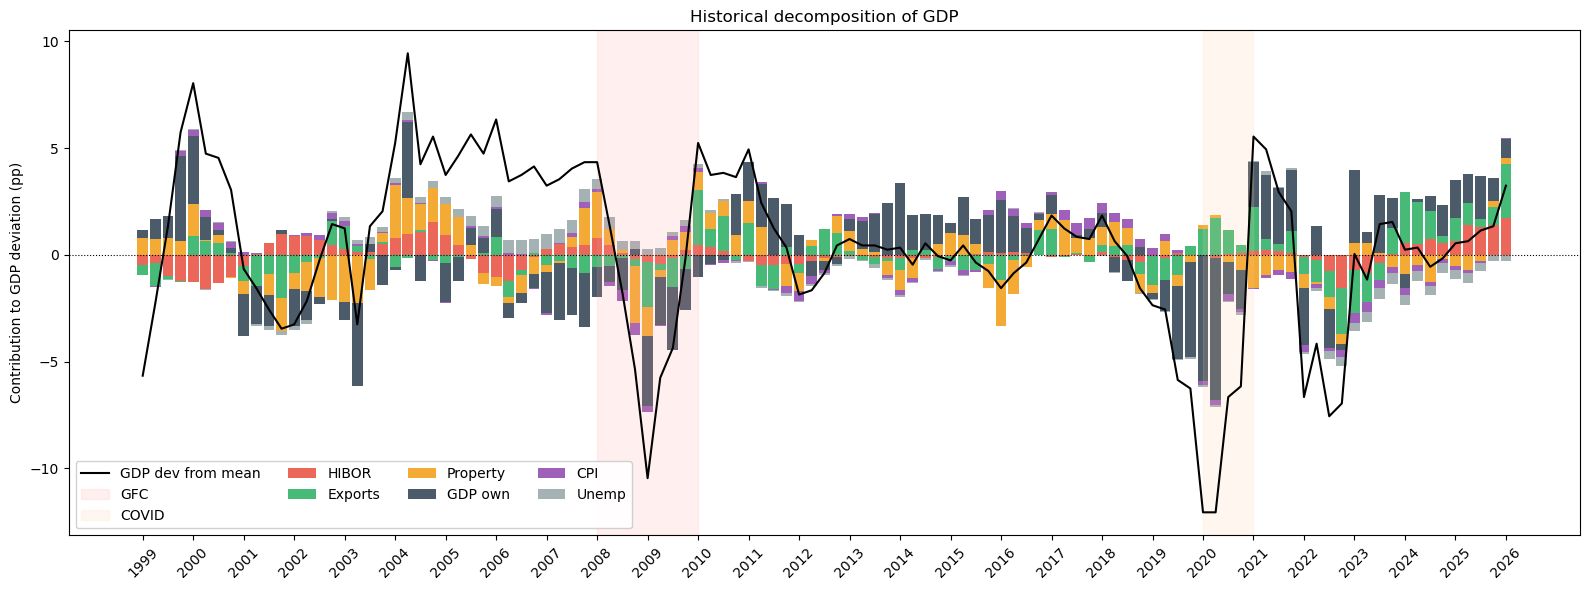

,Shock,% mean |contrib|
0,HIBOR,11.5
1,Exports,19.0
2,Property,20.7
3,GDP own,38.7
4,CPI,4.8
5,Unemp,5.3


,Shock,GFC avg pp
0,HIBOR,0.06
1,Exports,-0.75
2,Property,0.03
3,GDP own,-1.72
4,CPI,-0.11
5,Unemp,0.36


,Shock,COVID avg pp
0,HIBOR,0.01
1,Exports,1.10
2,Property,-0.17
3,GDP own,-3.98
4,CPI,-0.22
5,Unemp,-0.08


In [76]:
# Historical decomposition: accounting check, not headline.
assert 'bvar_c' in globals(), 'Run FEVD cell first.'
shock_labels = ['HIBOR', 'Exports', 'Property', 'GDP own', 'CPI', 'Unemp']
colors = ['#e74c3c', '#27ae60', '#f39c12', '#2c3e50', '#8e44ad', '#95a5a6']

hd = bvar_c.historical_decomposition(credibility_level=0.90)
gdp_i = idx_c['gdp_growth']
dates_hd = df.index[LAGS:LAGS + hd.shape[2]]
x = np.arange(hd.shape[2])

fig, ax = plt.subplots(figsize=(16, 6))
pos_bottom = np.zeros(len(x)); neg_bottom = np.zeros(len(x))
for j, label in enumerate(shock_labels):
    c = hd[gdp_i, j, :, 0]
    pos = np.where(c > 0, c, 0); neg = np.where(c < 0, c, 0)
    ax.bar(x, pos, bottom=pos_bottom, color=colors[j], alpha=0.85, label=label, width=0.85)
    ax.bar(x, neg, bottom=neg_bottom, color=colors[j], alpha=0.85, width=0.85)
    pos_bottom += pos; neg_bottom += neg

ax.plot(x, df['gdp_growth'].values[LAGS:LAGS + len(x)] - df['gdp_growth'].mean(), 'k-', lw=1.5, label='GDP dev from mean')
ax.axhline(0, color='k', lw=0.8, ls=':')
for start, end, label, color in [('2008-01-01', '2009-12-31', 'GFC', '#ff9999'), ('2020-01-01', '2020-12-31', 'COVID', '#ffcc99')]:
    s = np.searchsorted(dates_hd, pd.Timestamp(start)); e = np.searchsorted(dates_hd, pd.Timestamp(end))
    if s < len(x):
        ax.axvspan(s, min(e, len(x)-1), alpha=0.15, color=color, label=label)

tick_idx = range(0, len(x), 4)
ax.set_xticks(list(tick_idx)); ax.set_xticklabels([dates_hd[i].strftime('%Y') for i in tick_idx], rotation=45)
ax.set_ylabel('Contribution to GDP deviation (pp)')
ax.set_title('Historical decomposition of GDP')
ax.legend(loc='lower left', ncol=4, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'historical_decomp_gdp.png', dpi=150, bbox_inches='tight')
plt.show()

mean_abs = np.array([np.abs(hd[gdp_i, j, :, 0]).mean() for j in range(6)])
display(pd.DataFrame({'Shock': shock_labels, '% mean |contrib|': (mean_abs / mean_abs.sum() * 100).round(1)}))
for ep, start, end in [('GFC', '2008-01-01', '2009-12-31'), ('COVID', '2020-01-01', '2020-12-31')]:
    m = (dates_hd >= start) & (dates_hd <= end)
    display(pd.DataFrame({'Shock': shock_labels, f'{ep} avg pp': [round(hd[gdp_i, j, m, 0].mean(), 2) for j in range(6)]}))

### Cholesky ordering robustness: property ↔ GDP swap

FEVD h=8 — GDP variance decomposition
Shock          Canonical  Swap (GDP↔Prop)
-----------------------------------------
HIBOR                8.6              8.6
Exports             16.4             16.5
Property            20.6              2.3
GDP own             51.3             69.6
CPI                  1.8              1.7
Unemp                1.2              1.2


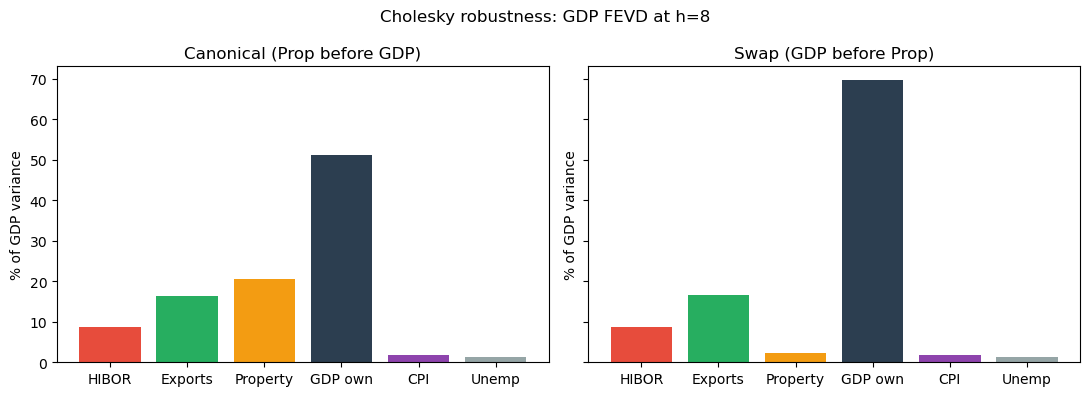

In [77]:
# Swap property (pos 2) and GDP (pos 3). Same hyperparams throughout.
assert 'fevd_c' in globals(), 'Run FEVD cell first.'

ENDOG_SWAP   = ['hibor_3m', 'hk_exports_china_yoy', 'gdp_growth',
                 'hk_property_price_qoq', 'cpi_inflation', 'unemployment']
AR_COEF_SWAP = [0.442, 0.627, 0.545, 0.418, 0.735, 0.991]

bvar_swap = MinnesotaBayesianVar(
    endogenous=df[ENDOG_SWAP].values.astype(float),
    exogenous=df[EXOG].values.astype(float),
    lags=LAGS, pi1=PI1, pi2=PI2, pi3=PI3,
    ar_coefficients=AR_COEF_SWAP,
    iterations=2000, credibility_level=0.90, verbose=False,
)
bvar_swap.estimate()
fevd_swap          = bvar_swap.forecast_error_variance_decomposition(h=8, credibility_level=0.90)
irf_swap, _        = bvar_swap.impulse_response_function(h=9, credibility_level=0.90)
irf_c_arr, _       = bvar_c.impulse_response_function(h=9, credibility_level=0.90)

# FEVD h=8 — GDP row
gdp_i_c    = ENDOG_CANONICAL.index('gdp_growth')
gdp_i_swap = ENDOG_SWAP.index('gdp_growth')
row_c    = fevd_c[gdp_i_c,    :, 7, 0] * 100
row_swap = fevd_swap[gdp_i_swap, :, 7, 0] * 100

shock_map = [('HIBOR', 0, 0), ('Exports', 1, 1), ('Property', 2, 3),
             ('GDP own', 3, 2), ('CPI', 4, 4), ('Unemp', 5, 5)]

print('FEVD h=8 — GDP variance decomposition')
print(f'{"Shock":<12} {"Canonical":>11} {"Swap (GDP↔Prop)":>16}')
print('-' * 41)
for label, ci, si in shock_map:
    print(f'{label:<12} {row_c[ci]:>11.1f} {row_swap[si]:>16.1f}')
print(f'\nJoint (Prop+GDP): canonical={row_c[2]+row_c[3]:.1f}%  swap={row_swap[3]+row_swap[2]:.1f}%')

# IRF: property → GDP under both orderings
prop_i_c    = ENDOG_CANONICAL.index('hk_property_price_qoq')
prop_i_swap = ENDOG_SWAP.index('hk_property_price_qoq')

print('\nIRF: property → GDP (90% credibility bands)')
print(f'{"h":<4} {"Canonical":>22}    {"Swap":>22}')
print('-' * 58)
for h in [1, 2, 3, 4]:
    lo_c  = irf_c_arr[gdp_i_c,    prop_i_c,    h, 1]
    med_c = irf_c_arr[gdp_i_c,    prop_i_c,    h, 0]
    hi_c  = irf_c_arr[gdp_i_c,    prop_i_c,    h, 2]
    lo_s  = irf_swap[ gdp_i_swap,  prop_i_swap, h, 1]
    med_s = irf_swap[ gdp_i_swap,  prop_i_swap, h, 0]
    hi_s  = irf_swap[ gdp_i_swap,  prop_i_swap, h, 2]
    sig_c = '*' if lo_c > 0 or hi_c < 0 else ' '
    sig_s = '*' if lo_s > 0 or hi_s < 0 else ' '
    print(f'h={h}  ({lo_c:>6.3f}, {med_c:>6.3f}, {hi_c:>6.3f}){sig_c}  ({lo_s:>6.3f}, {med_s:>6.3f}, {hi_s:>6.3f}){sig_s}')

# Plot: FEVD bars + IRF comparison
colors = ['#e74c3c', '#27ae60', '#f39c12', '#2c3e50', '#8e44ad', '#95a5a6']
shock_labels = [s[0] for s in shock_map]
vals_c    = [row_c[ci]    for _, ci, _  in shock_map]
vals_swap = [row_swap[si] for _, _,  si in shock_map]
horizons  = [1, 2, 3, 4]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, title in [
    (axes[0], vals_c,    'FEVD h=8: Canonical'),
    (axes[1], vals_swap, 'FEVD h=8: Swap (GDP↔Prop)'),
]:
    ax.bar(shock_labels, vals, color=colors)
    ax.set_ylabel('% of GDP variance')
    ax.set_title(title)

ax = axes[2]
med_c_irf = [irf_c_arr[gdp_i_c,   prop_i_c,    h, 0] for h in horizons]
lo_c_irf  = [irf_c_arr[gdp_i_c,   prop_i_c,    h, 1] for h in horizons]
hi_c_irf  = [irf_c_arr[gdp_i_c,   prop_i_c,    h, 2] for h in horizons]
med_s_irf = [irf_swap[gdp_i_swap,  prop_i_swap, h, 0] for h in horizons]
lo_s_irf  = [irf_swap[gdp_i_swap,  prop_i_swap, h, 1] for h in horizons]
hi_s_irf  = [irf_swap[gdp_i_swap,  prop_i_swap, h, 2] for h in horizons]
ax.plot(horizons, med_c_irf,  'b-o', label='Canonical')
ax.fill_between(horizons, lo_c_irf,  hi_c_irf,  alpha=0.15, color='blue')
ax.plot(horizons, med_s_irf, 'r--o', label='Swap')
ax.fill_between(horizons, lo_s_irf, hi_s_irf, alpha=0.15, color='red')
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel('Horizon (quarters)')
ax.set_title('IRF: Property → GDP')
ax.legend()

plt.suptitle('Cholesky robustness: property ↔ GDP swap')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'robustness_cholesky_swap.png', dpi=150, bbox_inches='tight')
plt.show()

## README figures

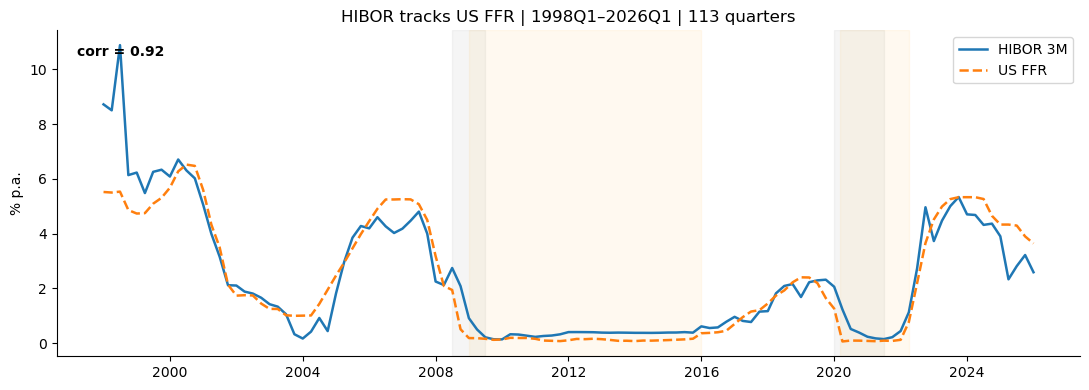

In [78]:
# README Fig 1: HIBOR vs US FFR
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df['hibor_3m'], lw=1.8, label='HIBOR 3M')
ax.plot(df.index, df['us_ffr'], lw=1.8, ls='--', label='US FFR')
for start, end, color, alpha in [
    ('2008-07-01', '2009-06-30', 'gray', 0.08),
    ('2020-01-01', '2021-06-30', 'gray', 0.08),
    ('2009-01-01', '2015-12-31', 'orange', 0.06),
    ('2020-03-01', '2022-03-31', 'orange', 0.06),
]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)
ax.text(0.02, 0.92, f'corr = {df["hibor_3m"].corr(df["us_ffr"]):.2f}', transform=ax.transAxes, fontweight='bold')
ax.set_title(f'HIBOR tracks US FFR | {SAMPLE_LABEL}')
ax.set_ylabel('% p.a.')
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'readme_hibor_ffr.png', dpi=150, bbox_inches='tight')
plt.show()